In [ ]:
#==============================
# IMPORT LIBRARIES
# ==============================
%pip install seaborn
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
print(sys.executable)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier



In [ ]:
# ==============================
# 1. Data Loading and Inspection
# ==============================
df = pd.read_csv("q1_heart_disease.csv")

print("Shape:", df.shape)
print("\nMissing Values BEFORE:\n", df.isnull().sum())


Shape: (800, 12)

Missing Values BEFORE:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [4]:
# haldling missing values
df = df.fillna(df.median(numeric_only=True))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values AFTER:\n", df.isnull().sum())



Missing Values AFTER:
 age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


C:\Users\Santosh\AppData\Local\Temp\ipykernel_26884\736174381.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


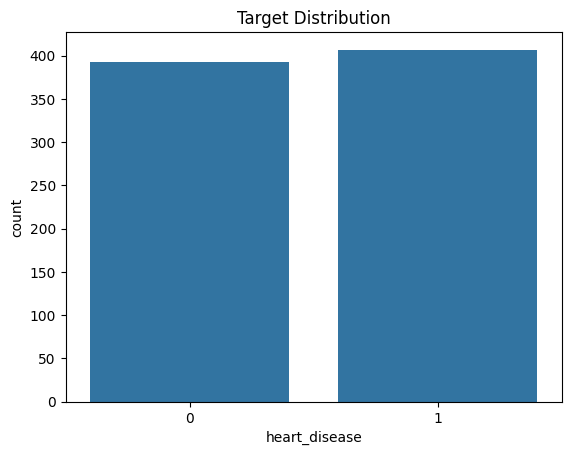

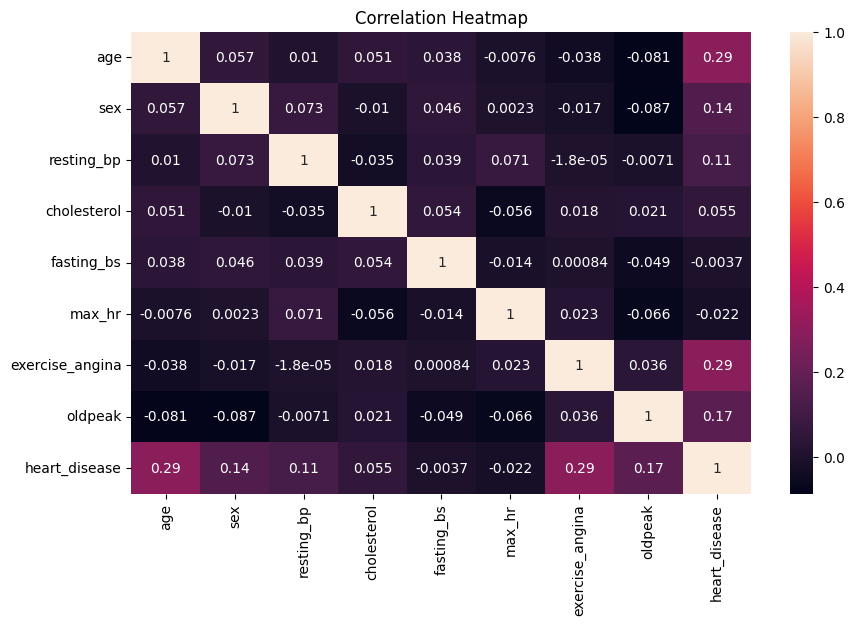

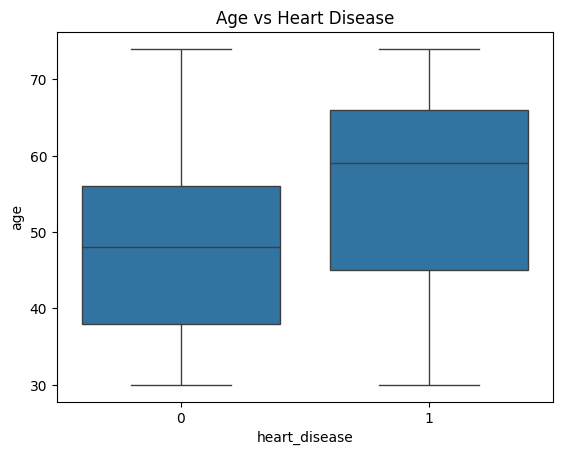

In [ ]:
# ==============================
# 2. Exploratory Data Analysis 
# ==============================
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()


In [6]:
# ==============================
# 3. Data Preprocessing 
# ==============================
df_encoded = pd.get_dummies(df, drop_first=True)

# 🔍 Final NaN check (important)
print("\nNaN after encoding:\n", df_encoded.isnull().sum())

# Safety cleanup
df_encoded = df_encoded.fillna(0)

X = df_encoded.drop("heart_disease", axis=1)
y = df_encoded["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


NaN after encoding:
 age                                  0
sex                                  0
resting_bp                           0
cholesterol                          0
fasting_bs                           0
max_hr                               0
exercise_angina                      0
oldpeak                              0
heart_disease                        0
chest_pain_type_atypical_angina      0
chest_pain_type_non_anginal          0
chest_pain_type_typical_angina       0
resting_ecg_normal                   0
resting_ecg_st_t_wave_abnormality    0
st_slope_flat                        0
st_slope_up                          0
dtype: int64


In [7]:
# ==============================
# 4. Model Training 
# ==============================
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("\nModels trained successfully ✅")




Models trained successfully ✅


In [8]:
# ==============================
# 5. Model Evaluation
# ==============================
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



Decision Tree
Confusion Matrix:
 [[57 22]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
  

In [9]:
# ==============================
# 6. Hyperparameter Tuning
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTuned Model Performance:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'max_depth': 10, 'n_estimators': 200}

Tuned Model Performance:
Confusion Matrix:
 [[57 22]
 [17 64]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160

